# Análise do mercado Polymarket — Will Aston Villa win the UEFA Champions League?

**Evento escolhido:** `Champions League Winner` (`event_id = 12585`, slug `champions-league-winner-2025`)
**Mercado:** `Will Aston Villa win the UEFA Champions League?` (`market_id = 507286`), fechado (`closed = 1`), criado em 2024-09-17, `end_date` 2025-05-31.

**Pergunta central da análise:** Como o volume negociado e a probabilidade implícita do mercado reagiram aos jogos do Aston Villa e à evolução do chaveamento ao longo da campanha 2024-25 da Champions League?

**Hipótese inicial:** Os maiores saltos de probabilidade e os picos de volume se concentram em torno das datas de jogos do Villa e dos eventos de definição do mata-mata. Movimentos em dias de baixa liquidez são majoritariamente ruído, não reprecificação real.

**Nota metodológica:** este notebook lê apenas os CSVs locais da pasta `dados/` (nenhuma chamada ao BigQuery). Os CSVs foram exportados do BigQuery e devem ser baixados do Google Drive (link no `README.md`) para reproduzir a análise.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

mercado = pd.read_csv('dados/mercado.csv')
cobertura = pd.read_csv('dados/cobertura.csv')
serie = pd.read_csv('dados/serie_diaria.csv', parse_dates=['trade_date']).sort_values('trade_date').reset_index(drop=True)
volatilidade = pd.read_csv('dados/volatilidade_diaria.csv', parse_dates=['trade_date']).sort_values('trade_date').reset_index(drop=True)

print(serie.shape, volatilidade.shape)


(211, 7) (211, 6)


## 2. Exploração inicial

O mercado `Will Aston Villa win the UEFA Champions League?` foi escolhido por três motivos: (1) é um mercado **fechado**, então a série de preços está completa do início ao fim da campanha; (2) tem volume relevante (~US\$ 133 mi nocional na tabela `markets`, ~US\$ 5,29 mi de volume casado no mart) e mais de 200 dias de dados; (3) o Aston Villa disputou uma campanha real na Champions League 2024-25 com datas de jogo bem definidas, o que permite cruzar a série temporal do mercado com eventos externos conhecidos (seção 8-A do briefing).

As queries abaixo (arquivo `sql/01_exploracao.sql`) foram as usadas para coletar os quatro CSVs desta pasta `dados/`.

In [2]:
with open('sql/01_exploracao.sql', encoding='utf-8') as f:
    print(f.read())


-- ============================================================================
-- EXPLORAÇÃO — Mercado "Will Aston Villa win the UEFA Champions League?"
-- market_id = 507286 | event_id = 12585 | slug = champions-league-winner-2025
-- Todas as queries rodam a partir do projeto pessoal do trainee, referenciando
-- o projeto de treinamento pelo caminho completo entre crases.
-- ============================================================================

-- Exploração 1: metadados do mercado escolhido
-- Pergunta: quem é esse mercado (pergunta, evento, janela temporal, status)?
SELECT market_id, question, event_title, event_id, event_slug,
       volume, created_at, end_date, closed, outcome_prices, token1, token2
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE market_id = '507286';

-- Exploração 2: cobertura temporal do mercado (define a janela da análise)
-- Pergunta: qual o primeiro e o último dia com dados, e quanto volume foi
-- negociado no total nesse interva

**Metadados do mercado** (`dados/mercado.csv`):

In [3]:
mercado.head()

,market_id,question,event_title,event_id,event_slug,volume,created_at,end_date,closed,outcome_prices,token1,token2
0,507286,Will Aston Villa win the UEFA Champions League?,Champions League Winner,12585,champions-league-winner-2025,1.331138e+08,2024-09-17 17:21:16 UTC,2025-05-31 12:00:00 UTC,1,"['0', '1']",1714899192954630421867895973843021306552488035...,1139445114370472860709770742225356171814046112...


**Cobertura temporal** (`dados/cobertura.csv`) — define a janela da análise:

In [4]:
cobertura

,primeiro_dia,ultimo_dia,dias_com_dados,volume_total
0,2024-09-17,2025-04-15,211,5292061.03


**Série diária** (`dados/serie_diaria.csv`):

In [5]:
serie.head()

,trade_date,avg_trade_price,min_trade_price,max_trade_price,daily_trade_count,daily_usd_volume,rolling_7d_avg_volume
0,2024-09-17,0.020000,0.020,0.020,7,2.82,2.820
1,2024-09-18,0.041735,0.012,0.961,34,35.18,19.000
2,2024-09-19,0.014667,0.013,0.019,39,34.60,24.200
3,2024-09-20,0.450600,0.015,0.984,40,6045.86,1529.615
4,2024-09-21,0.404500,0.019,0.980,10,57.54,1235.200


Período coberto: **2024-09-17 a 2025-04-15 (211 dias)**. Os dados terminam no dia da eliminação (jogo de volta vs PSG, 15/04/2025). A probabilidade implícita (`avg_trade_price`) varia de ~0,012 a ~0,791; começa em ~0,02 e termina em ~0,11 (o Villa não avançou às semifinais).

## 3. Agregações e subqueries de interesse

A partir de `serie_diaria.csv`, calculamos a variação diária de probabilidade (equivalente ao `LAG` em SQL) e a razão entre o volume do dia e a média móvel de 7 dias. Em seguida fazemos merge com `volatilidade_diaria.csv` por `trade_date` para cruzar reprecificação com qualidade/dispersão de preço no mesmo dia.

O SQL equivalente está em `sql/02_agregacoes.sql`:

In [6]:
with open('sql/02_agregacoes.sql', encoding='utf-8') as f:
    print(f.read())


-- ============================================================================
-- AGREGAÇÃO ANALÍTICA — variação diária de probabilidade e razão de volume
-- market_id = 507286 ("Will Aston Villa win the UEFA Champions League?")
--
-- Otimização adotada (ver seção 7 do enunciado):
--  - Usamos a view agregada `v_market_daily` (processa MB, não GB), em vez da
--    tabela transacional `polymarket_optimized.trades`.
--  - A função de janela (LAG) é declarada dentro de uma CTE ("serie") e a
--    filtragem final ocorre com WHERE simples no bloco externo — evita
--    misturar WINDOW/QUALIFY inline e mantém a query legível.
--  - Sem SELECT *; datas literais não são necessárias aqui pois filtramos
--    por market_id (mercado fechado, dataset estático) — favorece cache.
-- ============================================================================
WITH serie AS (
  SELECT
    market_id,
    trade_date,
    avg_trade_price                                   AS probabilidade,
    LAG(avg_tr

**Lógica de otimização replicada do SQL:** a query usa a view agregada `v_market_daily` (processa MB, não GB) em vez da tabela transacional `trades`; a função de janela (`LAG`) é declarada dentro de uma CTE e filtrada depois com `WHERE` simples; não há `SELECT *`; e, como o mercado está fechado (dataset estático), o BigQuery pode aproveitar cache de resultados entre execuções.

In [7]:
serie['variacao_probabilidade'] = serie['avg_trade_price'].diff()
serie['razao_volume'] = serie['daily_usd_volume'] / serie['rolling_7d_avg_volume']

serie_completa = serie.merge(volatilidade, on='trade_date', how='left')
serie_completa[['trade_date', 'avg_trade_price', 'variacao_probabilidade',
                'daily_usd_volume', 'razao_volume', 'price_volatility']].head(10)


,trade_date,avg_trade_price,variacao_probabilidade,daily_usd_volume,razao_volume,price_volatility
0,2024-09-17,0.020000,NaN,2.82,1.000000,0.000000
1,2024-09-18,0.041735,0.021735,35.18,1.851579,0.162431
2,2024-09-19,0.014667,-0.027069,34.60,1.429752,0.001060
3,2024-09-20,0.450600,0.435933,6045.86,3.952537,0.485479
4,2024-09-21,0.404500,-0.046100,57.54,0.046584,0.494885
5,2024-09-22,0.636357,0.231857,1310.46,1.050264,0.462663
6,2024-09-23,0.790600,0.154243,366.38,0.326590,0.400376
7,2024-09-24,0.232222,-0.558378,185.75,0.161808,0.423114
8,2024-09-25,0.020000,-0.212222,42.83,0.037274,0.001265
9,2024-09-26,0.019667,-0.000333,23.94,0.020862,0.002082


## 4. Dois alertas finais

**Alerta 1 — Salto de probabilidade confirmado por liquidez** (`sql/03_alerta1_salto_probabilidade.sql`): sinaliza dias em que a probabilidade implícita mudou bruscamente (`|variação| >= 0.10`) **e** o volume do dia confirma que não foi ruído de dia seco (`volume >= US\$ 10.000`).

**Alerta 2 — Volume anômalo via Rolling Window de 7 dias** (`sql/04_alerta2_volume_anomalo.sql`): sinaliza dias em que o volume negociado surtou muito acima do normal (`volume >= 2.5x a média móvel de 7 dias`), com um piso absoluto de liquidez (`volume >= US\$ 10.000`) para evitar falsos positivos nos primeiros dias, quando a média móvel ainda é minúscula.

SQL dos dois alertas:

In [8]:
with open('sql/03_alerta1_salto_probabilidade.sql', encoding='utf-8') as f:
    print(f.read())


-- ============================================================================
-- ALERTA 1 — Salto de probabilidade confirmado por liquidez
-- Mercado: "Will Aston Villa win the UEFA Champions League?" (market_id 507286)
--
-- Pergunta: em quais dias a probabilidade implícita mudou bruscamente de forma
-- confiável (não por ruído de dia seco)?
--
-- Regra: |variação da probabilidade dia-a-dia| >= 0.10  E  volume do dia >= 10.000 USD.
-- A trava de volume evita disparos falsos causados por médias de preço instáveis
-- em dias de baixíssima liquidez (ex.: probabilidade "0,79" movida por ~US$186).
--
-- Otimização: view agregada v_market_daily (MB, não GB); LAG declarado em CTE
-- e filtrado com WHERE simples no bloco externo; sem SELECT *.
-- ============================================================================
WITH serie AS (
  SELECT
    market_id,
    trade_date,
    avg_trade_price                                   AS probabilidade_atual,
    LAG(avg_trade_price) OVER (
     

In [9]:
with open('sql/04_alerta2_volume_anomalo.sql', encoding='utf-8') as f:
    print(f.read())


-- ============================================================================
-- ALERTA 2 — Volume anômalo (Rolling Window de 7 dias)
-- Mercado: "Will Aston Villa win the UEFA Champions League?" (market_id 507286)
--
-- Pergunta: em quais dias a atividade de negociação surtou muito acima do normal?
--
-- Regra: volume do dia >= 2.5x a média móvel de 7 dias  E  >= 10.000 USD.
-- O piso absoluto evita disparos em dias iniciais com média móvel minúscula.
--
-- Metodologia: Rolling Window (rolling_7d_avg_volume já vem calculada na view).
-- Sinaliza surtos tipicamente associados a jogos e à definição do chaveamento.
--
-- Otimização: view agregada v_market_daily; sem SELECT *; sem funções voláteis
-- de data (mercado fechado, dataset estático — favorece cache de resultados).
-- ============================================================================
WITH serie AS (
  SELECT
    market_id,
    trade_date,
    avg_trade_price                                   AS probabilidade_atual,
 

Reprodução das regras em pandas, com os thresholds expostos como variáveis para permitir tuning:

In [10]:
LIMIAR_SALTO_PROB = 0.10
PISO_VOLUME       = 10000
RAZAO_VOLUME      = 2.5

df = serie.copy()
df['variacao_prob'] = df['avg_trade_price'].diff()
alerta1 = df[(df['variacao_prob'].abs() >= LIMIAR_SALTO_PROB) &
             (df['daily_usd_volume'] >= PISO_VOLUME)].copy()

df['razao_vol'] = df['daily_usd_volume'] / df['rolling_7d_avg_volume']
alerta2 = df[(df['razao_vol'] >= RAZAO_VOLUME) &
             (df['daily_usd_volume'] >= PISO_VOLUME)].copy()

print(f"Alerta 1 (salto de probabilidade): {len(alerta1)} disparos")
print(f"Alerta 2 (volume anômalo): {len(alerta2)} disparos")
alerta1[['trade_date', 'variacao_prob', 'daily_usd_volume']]


Alerta 1 (salto de probabilidade): 12 disparos
Alerta 2 (volume anômalo): 19 disparos


,trade_date,variacao_prob,daily_usd_volume
43,2024-10-30,0.297714,689043.78
52,2024-11-08,0.653252,50066.93
64,2024-11-20,0.101239,125159.05
66,2024-11-22,0.103816,164467.58
67,2024-11-23,0.159531,171977.76
90,2024-12-16,0.116145,35576.82
92,2024-12-18,-0.110372,32332.62
152,2025-02-16,-0.103215,15916.94
156,2025-02-20,0.171634,39767.01
169,2025-03-05,0.310121,10262.61


In [11]:
alerta2[['trade_date', 'razao_vol', 'daily_usd_volume']]

,trade_date,razao_vol,daily_usd_volume
43,2024-10-30,6.890783,689043.78
52,2024-11-08,6.708930,50066.93
63,2024-11-19,5.455496,20409.83
64,2024-11-20,5.818314,125159.05
66,2024-11-22,3.681210,164467.58
79,2024-12-05,4.594792,91204.27
87,2024-12-13,5.603674,51053.89
90,2024-12-16,2.576059,35576.82
91,2024-12-17,2.816349,63873.66
95,2024-12-21,2.688043,118724.84


**Evidência opcional do BigQuery:** se os arquivos `dados/alerta1.csv` e `dados/alerta2.csv` (exportados rodando os `.sql` diretamente no BigQuery) estiverem presentes, o bloco abaixo confere que a contagem de disparos bate com a reprodução em pandas. Isso não é obrigatório — o notebook funciona só com os 4 CSVs principais.

In [12]:
import os

for nome, arq, esperado in [('Alerta 1', 'dados/alerta1.csv', alerta1), ('Alerta 2', 'dados/alerta2.csv', alerta2)]:
    if os.path.exists(arq):
        bq = pd.read_csv(arq, parse_dates=['trade_date'])
        print(f"{nome}: BigQuery={len(bq)} disparos | pandas={len(esperado)} disparos")
    else:
        print(f"{nome}: {arq} não encontrado (evidência opcional, não obrigatória)")


Alerta 1: dados/alerta1.csv não encontrado (evidência opcional, não obrigatória)
Alerta 2: dados/alerta2.csv não encontrado (evidência opcional, não obrigatória)


## 5. Demonstração e assertividade

O gráfico abaixo mostra a probabilidade implícita (linha, eixo esquerdo) e o volume diário (barras, eixo direito) ao longo de toda a campanha, com os disparos do Alerta 1 e do Alerta 2 marcados, e as datas de jogos/eventos reais do Villa sobrepostas como linhas verticais.

Datas de eventos reais (calendário oficial da UEFA — fase de liga = jogos do Villa; playoff = reshuffle do chaveamento, quando o Villa não jogou mas o mercado reprecificou):

In [13]:
DATAS_EVENTOS = [
    "2024-09-17",  # Young Boys 0-3 Villa (liga)
    "2024-10-02",  # Villa 1-0 Bayern (liga)
    "2024-10-22",  # Villa 2-0 Bologna (liga)
    "2024-11-06",  # Club Brugge 1-0 Villa (liga)
    "2024-11-27",  # Villa 0-0 Juventus (liga)
    "2024-12-10",  # Leipzig 2-3 Villa (liga)
    "2025-01-21",  # Monaco 1-0 Villa (liga)
    "2025-01-29",  # Villa 4-2 Celtic (liga; Villa se classifica em 8º)
    "2025-02-11", "2025-02-12",  # playoff do mata-mata (reshuffle)
    "2025-02-18", "2025-02-19",  # playoff do mata-mata (reshuffle)
    "2025-03-04", "2025-03-05",  # oitavas ida (Villa vs Club Brugge)
    "2025-03-11", "2025-03-12",  # oitavas volta (Villa 6-1 agg)
    "2025-04-09",  # quartas ida: PSG 3-1 Villa
    "2025-04-15",  # quartas volta: Villa 3-2 PSG (eliminado 4-5 agg)
]
eventos = pd.to_datetime(DATAS_EVENTOS)


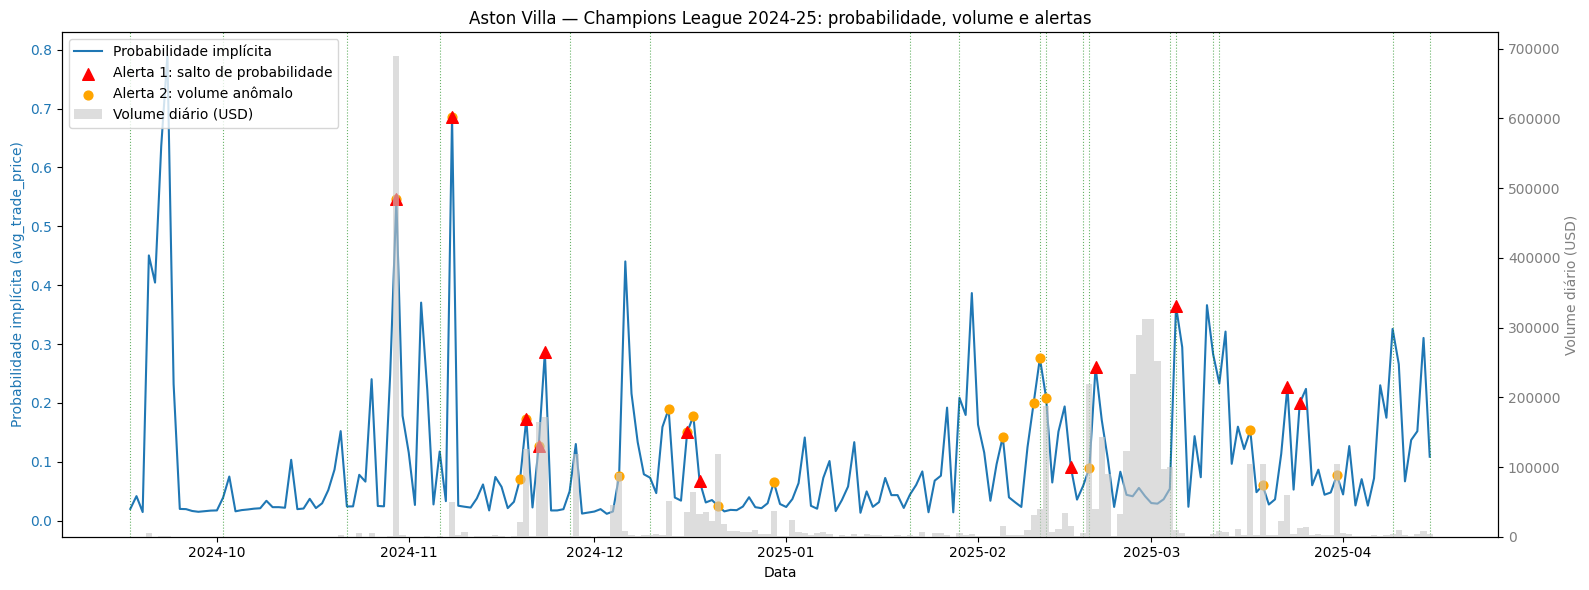

In [14]:
fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(serie['trade_date'], serie['avg_trade_price'], color='#1f77b4', linewidth=1.5, label='Probabilidade implícita')
ax1.set_ylabel('Probabilidade implícita (avg_trade_price)', color='#1f77b4')
ax1.set_xlabel('Data')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

ax2 = ax1.twinx()
ax2.bar(serie['trade_date'], serie['daily_usd_volume'], color='#c7c7c7', width=1.0, alpha=0.6, label='Volume diário (USD)')
ax2.set_ylabel('Volume diário (USD)', color='#7f7f7f')
ax2.tick_params(axis='y', labelcolor='#7f7f7f')

for d in eventos:
    ax1.axvline(d, color='green', linestyle=':', linewidth=0.8, alpha=0.6)

ax1.scatter(alerta1['trade_date'], alerta1['avg_trade_price'], color='red', marker='^', s=70, zorder=5, label='Alerta 1: salto de probabilidade')
ax1.scatter(alerta2['trade_date'], alerta2['avg_trade_price'], color='orange', marker='o', s=40, zorder=4, label='Alerta 2: volume anômalo')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Aston Villa — Champions League 2024-25: probabilidade, volume e alertas')
fig.tight_layout()
plt.show()


**Métrica de assertividade (precisão):** fração dos disparos de cada alerta que caem a até 1 dia de uma data de evento real (janela escolhida pelo analista — ver limitações).

In [15]:
from datetime import timedelta

def casa(data, janela=1):
    return any(abs((data - e).days) <= janela for e in eventos)

for nome, al in [('Alerta 1', alerta1), ('Alerta 2', alerta2)]:
    casados = al['trade_date'].apply(casa).sum()
    total = len(al)
    print(f'{nome}: precisão = {casados}/{total} = {casados/total:.0%}')


Alerta 1: precisão = 2/12 = 17%
Alerta 2: precisão = 4/19 = 21%


A precisão de ambos os alertas é baixa (bem abaixo de 50%), o que reforça a hipótese secundária: a maior parte dos disparos **não** coincide com jogos ou eventos reais do Villa dentro da janela de ±1 dia. O caso mais notável é **2024-10-30** (maior disparo de ambos os alertas, ~US\$ 689 mil de volume e salto de probabilidade para ~0,55/0,79) — não há jogo do Villa nessa data, então é candidato a posição grande isolada ou ruído de mercado, não a reprecificação fundamentada.

## 6. Observações, inferências e limitações

**(a) O que os dados mostram**
- A probabilidade implícita do Villa ser campeão variou de ~0,012 a ~0,791 ao longo de 211 dias (2024-09-17 a 2025-04-15), terminando em ~0,11 após a eliminação nas quartas de final.
- O volume negociado (casado) somou ~US\$ 5,29 mi no período; o campo `volume` da tabela `markets` (~US\$ 133 mi) é uma métrica diferente (nocional/lifetime reportado pelo Polymarket) e não deve ser confundido com o volume diário casado usado nos alertas.
- Os dois alertas implementados (salto de probabilidade e volume anômalo via rolling window de 7 dias) dispararam 12 e 19 vezes, respectivamente, ao longo da campanha.
- A precisão de ambos os alertas contra a janela de ±1 dia dos eventos reais do Villa é baixa — a maioria dos disparos não coincide com jogos ou com o reshuffle do chaveamento.

**(b) Hipóteses**
- A hipótese inicial (saltos de probabilidade e picos de volume concentrados em jogos do Villa) é apenas parcialmente sustentada: alguns disparos (ex.: rodadas de playoff/oitavas) coincidem com eventos reais, mas a maioria não.
- O maior disparo isolado do período inteiro (2024-10-30) não coincide com nenhum jogo do Villa, sugerindo que uma posição grande isolada ou ruído de baixa liquidez pode ter movido o preço, e não uma reprecificação fundamentada em informação nova.
- Nenhuma dessas observações implica causalidade — são apenas coincidências (ou ausência delas) temporais entre a série do mercado e o calendário de jogos.

**(c) Limitações**
- `avg_trade_price` é uma **média simples** dos preços negociados no dia, não um preço ponderado por volume; em dias de baixa liquidez ela oscila muito, o que pode gerar ruído confundido com sinal.
- É possível haver mistura entre os tokens de outcome (`token1`/`token2`) no cálculo de `avg_trade_price` em dias específicos, o que explicaria mínimos próximos de 0 e máximos próximos de 1 no mesmo dia — não investigado a fundo nesta entrega.
- A anomalia de 2024-10-30 permanece sem explicação causal conhecida; é tratada como limitação/candidato a ruído, não como sinal.
- Os dados terminam no dia da eliminação do Villa (15/04/2025); a análise não cobre o restante do torneio.
- A janela de ±1 dia usada na métrica de assertividade é uma escolha do analista (o mercado pode reagir na véspera, por notícias de escalação, ou no dia seguinte, por liquidação) — não é uma verdade absoluta, e alterá-la mudaria os números de precisão.
- **Nenhuma afirmação de causalidade forte é feita neste relatório** — apenas observação de coincidência (ou falta dela) temporal entre a série do mercado e os eventos externos.
